# EXXA General Test — Unsupervised Clustering of Protoplanetary Disks
**ML4Sci GSoC 2026**

**Author:** Jay Prajapati  
**Email:** jayp222001@gmail.com  
**GitHub:** https://github.com/coder-jayp

---

**Goal:** Automatically discover morphological groups in synthetic ALMA continuum
observations using unsupervised machine learning — with no labels provided.

**Key design decisions:**
- **De-projection:** Image moment ellipse fitting corrects inclination before any feature extraction — prevents clustering by viewing angle
- **Physics-motivated features:** 27-dimensional vector targeting rings, gaps, FFT periodicity — excludes total flux and brightness
- **UMAP over PCA:** Preserves non-linear manifold structure of disk morphology space
- **Dual UMAP:** 5D for clustering, 2D for visualization — separates concerns
- **Dynamic K selection:** Silhouette, Davies-Bouldin, Calinski-Harabasz evaluated across K=2–6
- **K=3 override:** Statistical optimum varies by dataset; K=3 chosen for richer physical interpretation with automatic fallback if separation is suboptimal
- **Data augmentation:** Random rotation and flipping applied — physically valid for rotationally symmetric disk emission
- **Data-driven labels:** Physics labels derived from centroid feature values
- **Scale-invariant features:** StandardScaler applied before UMAP — prevents feature magnitude bias
- **Full inference pipeline:** All trained models saved to disk — withheld data requires no retraining

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ENVIRONMENT SETUP

!pip install -q astropy umap-learn opencv-python-headless joblib

print("Environment initialization complete. All dependencies are active.")

Environment initialization complete. All dependencies are active.


In [ ]:
# IMPORTS

import os
import re
import warnings
import joblib
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import umap

from glob import glob
from astropy.io import fits
from scipy.signal import find_peaks
from scipy.fft import fft
from scipy.ndimage import rotate, zoom
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
print("System environment successfully configured.")

System environment successfully configured.


## Configuration
- All paths and hyperparameters are centralised here
- To retrain on a new dataset, only `DATA_FOLDER` and `SAVE_DIR` need to be updated

In [ ]:
# CONFIGURATION

# File I/O Paths
DATA_FOLDER  = "/content/drive/MyDrive/continuum_data_subset/"
SAVE_DIR = "/content/drive/MyDrive/EXXA_General_Test_Outputs"

MAX_RADIUS       = 270   # radial profile length in pixels
UMAP_N_NEIGHBORS = 15    # controls local vs global structure in UMAP embedding
UMAP_MIN_DIST    = 0.1   # minimum distance between points in UMAP space
K_RANGE          = range(2, 7)  # cluster counts evaluated during selection
KMEANS_NINIT     = 20    # Initializations to mitigate local optima
RANDOM_STATE     = 42

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Configuration loaded. Outputs: {SAVE_DIR}")

Configuration loaded. Outputs: /content/drive/MyDrive/EXXA_General_Test_Outputs


## Helper Functions

**`deproject_disk()`**
- Technical Challenge: inclined disks appear elliptical → clustering separates by viewing angle, not physics
- Implementation Strategy: fit ellipse via image moments → rotate + stretch to face-on
- Guard: skips correction if axis ratio > 0.9 (already face-on)

**`radial_profile()`**
- Planet-disk interactions are radial → rings and gaps are concentric
- Azimuthal averaging collapses 2D → 1D while preserving structural information
- Rotation-invariant by construction
- Uses `np.bincount` for O(N) efficiency

**`extract_features()` — 27-dimensional vector**

| Group | Features | Why |
|-------|----------|-----|
| Substructure | Ring count, gap count | Direct planet signature |
| Statistics | Variance, std, dynamic range, texture | Disk complexity |
| Outer disk | Mean flux beyond 50px | Extended planet-driven emission |
| FFT | 20 low-frequency amplitudes | Detects periodic ring spacing |

- Total flux and peak brightness deliberately excluded (correlate with disk mass, not planet presence)
- Dynamic prominence threshold adapts to each disk's contrast level

In [ ]:
# HELPER FUNCTIONS

# De-projection (geometry normalisation)

def deproject_disk(img: np.ndarray) -> np.ndarray:
    """
    Corrects for disk inclination and position angle by fitting an ellipse
    to the intensity distribution, then warping to a face-on (circular) view.

    Why This Matters:
        ALMA images protoplanetary disks from arbitrary viewing angles. An
        inclined disk appears as an ellipse. Without correction, an unsupervised
        model will cluster disks by their viewing angle (ellipse shape) rather
        than by physical substructure (rings, gaps). De-projection removes this
        confound so that clusters reflect planet-driven morphology.

    Sanity checks built in:
        - If ratio > 0.9 the disk is already nearly face-on; skip stretching.
        - Ratio is clipped to [0.3, 1.0] to prevent extreme warps on noisy images.
        - Output is always returned at the original (H, W) shape.

    Parameters
    ----------
    img : np.ndarray, shape (H, W), float32, NaN-free

    Returns
    -------
    np.ndarray, shape (H, W) — de-projected image
    """
    h, w = img.shape

    thresh = np.percentile(img, 50)
    binary = (img > thresh).astype(np.uint8)

    moments = cv2.moments(binary)
    if moments["m00"] == 0:
        return img

    pa = 0.5 * np.arctan2(
        2 * moments["mu11"],
        moments["mu20"] - moments["mu02"],
    )

    term1 = moments["mu20"] + moments["mu02"]
    term2 = np.sqrt(4 * moments["mu11"] ** 2 + (moments["mu20"] - moments["mu02"]) ** 2)
    major = np.sqrt(max(0.5 * (term1 + term2), 0))
    minor = np.sqrt(max(0.5 * (term1 - term2), 0))

    ratio = float(np.clip(minor / major if major > 1e-6 else 1.0, 0.3, 1.0))

    if ratio > 0.9:
        return img

    rotated     = rotate(img, np.degrees(pa), reshape=False, order=1)
    deprojected = zoom(rotated, (1.0 / ratio, 1.0), order=1)

    new_h   = deprojected.shape[0]
    start_h = max((new_h - h) // 2, 0)
    cropped = deprojected[start_h : start_h + h, :w]

    if cropped.shape != (h, w):
        cropped = cv2.resize(cropped, (w, h))

    return cropped.astype(img.dtype)


# Radial Profile

def radial_profile(img: np.ndarray, max_r: int = MAX_RADIUS) -> np.ndarray:
    """
    Computes the 1D azimuthal average of a 2D disk image.

    WHY THIS MATTERS:
        Protoplanetary disk physics is primarily radial — planet-disk interactions
        open concentric gaps and drive ring formation at characteristic radii.
        Collapsing to a 1D radial profile captures this structural information
        while being rotation-invariant (unaffected by residual position angle).

    Uses np.bincount for O(N) efficiency instead of nested loops.

    Parameters
    ----------
    img   : np.ndarray, shape (H, W)
    max_r : int — maximum radius in pixels

    Returns
    -------
    np.ndarray, shape (max_r,) — mean intensity at each integer radius
    """
    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)

    tbin = np.bincount(r.ravel(), img.ravel(), minlength=max_r + 1)
    nr   = np.bincount(r.ravel(),              minlength=max_r + 1)
    profile = tbin / np.maximum(nr, 1.0)
    return profile[:max_r]

# Feature Extraction

def extract_features(img: np.ndarray) -> np.ndarray:
    """
    Extracts a physics-motivated, scale-invariant feature vector from one disk.

    Feature groups:

      Group 1 — Substructure counts (2 features)
          - Number of radial peaks (rings)
          - Number of radial dips  (gaps)
          WHY: Planet-disk interactions open gaps and launch pressure bumps that
          accumulate dust into rings. More/deeper substructure implies more
          massive or numerous planets.

      Group 2 — Profile statistics (4 features)
          - Variance, std, dynamic range, texture (mean |d/dr|)
          WHY: A smooth, planet-free disk has a monotonically declining radial
          profile (low variance). Substructure inflates these metrics. These
          capture how 'complex' the dust distribution is.

      Group 3 — Outer disk signal (1 feature)
          - Mean intensity beyond 50px radius
          WHY: Planet-driven spirals and pressure bumps can concentrate dust far
          from the star. High outer-disk emission suggests a more extended or
          structured disk.

      Group 4 — FFT power spectrum (20 features)
          - log1p of the first 20 low-frequency Fourier amplitudes of the profile
          WHY: Regularly spaced rings (characteristic of multiple planets or
          resonant structures) produce peaks in the power spectrum. Captures
          periodicity that simple peak-counting might miss.

    Deliberately EXCLUDED:
          - Total flux / peak brightness → correlated with disk mass and distance,
            NOT with planet presence. Including these would cluster by disk mass.
          - Annular brightness bins → directly encodes viewing-angle-dependent
            geometry after de-projection imperfections.

    Parameters
    ----------
    img : np.ndarray, shape (H, W) — de-projected, NaN-free, float32

    Returns
    -------
    np.ndarray, shape (27,)
    """

    img_c = np.clip(img, 0, None)
    p99   = np.percentile(img_c, 99.9) + 1e-10
    img_n = np.clip(img_c / p99, 0, 1.5)

    profile = radial_profile(img_n)
    profile = profile / (profile.max() + 1e-10)

    dyn_prom = (profile.max() - profile.min()) * 0.05
    peaks, _ = find_peaks( profile, prominence=dyn_prom, distance=5)
    dips,  _ = find_peaks(-profile, prominence=dyn_prom, distance=5)

    f_substructure = np.array([float(len(peaks)), float(len(dips))])

    f_stats = np.array([
        np.var(profile),
        np.std(profile),
        profile.max() - profile.min(),
        np.mean(np.abs(np.diff(profile))),
    ])

    f_outer = np.array([
        np.mean(profile[50:]) if len(profile) > 50 else 0.0,
    ])

    fft_vals  = np.abs(fft(profile))[:MAX_RADIUS // 2]
    f_fourier = np.log1p(fft_vals[1:21])

    return np.concatenate([f_substructure, f_stats, f_outer, f_fourier])  # shape (27,)


def derive_physics_labels(X_scaled: np.ndarray, labels: np.ndarray) -> dict:
    """
    Assigns interpretable physics labels using two discriminators:
        - Variance (index 2): highest → Gap-Dominated (large brightness contrast)
        - Ring count (index 0): highest among remaining → Multi-Ring / Planet-Rich
        - Remaining cluster  → Smooth / Planet-Free
    """
    unique_labels = np.unique(labels)
    centroids = {
        k: X_scaled[labels == k].mean(axis=0)
        for k in unique_labels
    }

    variance   = {k: centroids[k][2] for k in unique_labels}
    ring_count = {k: centroids[k][0] for k in unique_labels}

    # Step 1: highest variance → Gap-Dominated
    gap_cluster = max(variance, key=variance.get)

    # Step 2: among remaining, highest ring count → Multi-Ring
    remaining = [k for k in unique_labels if k != gap_cluster]
    ring_cluster = max(remaining, key=lambda k: ring_count[k])

    # Step 3: everything else → Smooth
    physics_map = {}
    physics_map[gap_cluster]  = "Gap-Dominated / Transitional"
    physics_map[ring_cluster] = "Multi-Ring / Planet-Rich"
    for k in unique_labels:
        if k not in physics_map:
            physics_map[k] = "Smooth / Planet-Free"

    return physics_map

## Data Loading
- Format: FITS datacube with 4 channels — only channel 0 (Stokes I continuum) used
- `memmap=True` — lazy loading, avoids RAM overflow
- `float32` — halves memory vs float64
- `nan_to_num` — replaces NaN/Inf common at interferometric image edges

In [ ]:
# DATA LOADING

fits_files = sorted(glob(os.path.join(DATA_FOLDER, "*.fits")))
if not fits_files:
    raise FileNotFoundError(f"No .fits files found in: {DATA_FOLDER}")

print(f"Found {len(fits_files)} .fits files.")

disk_images   = []
disk_metadata = []

for file in fits_files:
    with fits.open(file, memmap=True) as hdul:
        raw = np.squeeze(hdul[0].data[0]).astype(np.float32)
        img = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

        meta = {
            "filename": os.path.basename(file),
            "object":   hdul[0].header.get("OBJECT", "Unknown"),
            "shape":    img.shape,
        }
        if img.shape != (600, 600):
            print(f"Unexpected shape {img.shape} in {meta['filename']}")

        disk_images.append(img)
        disk_metadata.append(meta)

disk_images = np.array(disk_images, dtype=np.float32)

print(f"Loaded {len(disk_images)} images.")
print(f"Dataset RAM: {disk_images.nbytes / 1e6:.1f} MB")
print(f"All finite: {np.all(np.isfinite(disk_images))}")

Found 150 .fits files.
Loaded 150 images.
Dataset RAM: 216.0 MB
All finite: True


## Ground Truth
- Extracted from filenames for **post-hoc evaluation only** — never seen by the model
- Filename integers encode simulation run IDs, not discrete planet counts
  (verified programmatically in the diagnostic cell below)
- ARI therefore omitted — cluster validity assessed via internal metrics only

In [ ]:
# GROUND TRUTH EXTRACTION (from filenames)

planet_ns = []
for meta in disk_metadata:
    match = re.search(r"planet(\d+)_", meta["filename"])
    planet_ns.append(int(match.group(1)) if match else -1)

planet_ns = np.array(planet_ns)

print(f"Unique simulation IDs: {np.unique(planet_ns)}")
print(f"Total labelled: {(planet_ns >= 0).sum()}  |  Unknown: {(planet_ns < 0).sum()}")

Unique simulation IDs: [  0   1   2   3   4   5   6   7   8   9  10  11  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  40  41  42  43  44  45  47  48  50  51  53  54  55  56  57  60
  64  68  69  70  72  80  83  84  86  88  89  92  96  97  99 100 101 102
 103]
Total labelled: 150  |  Unknown: 0


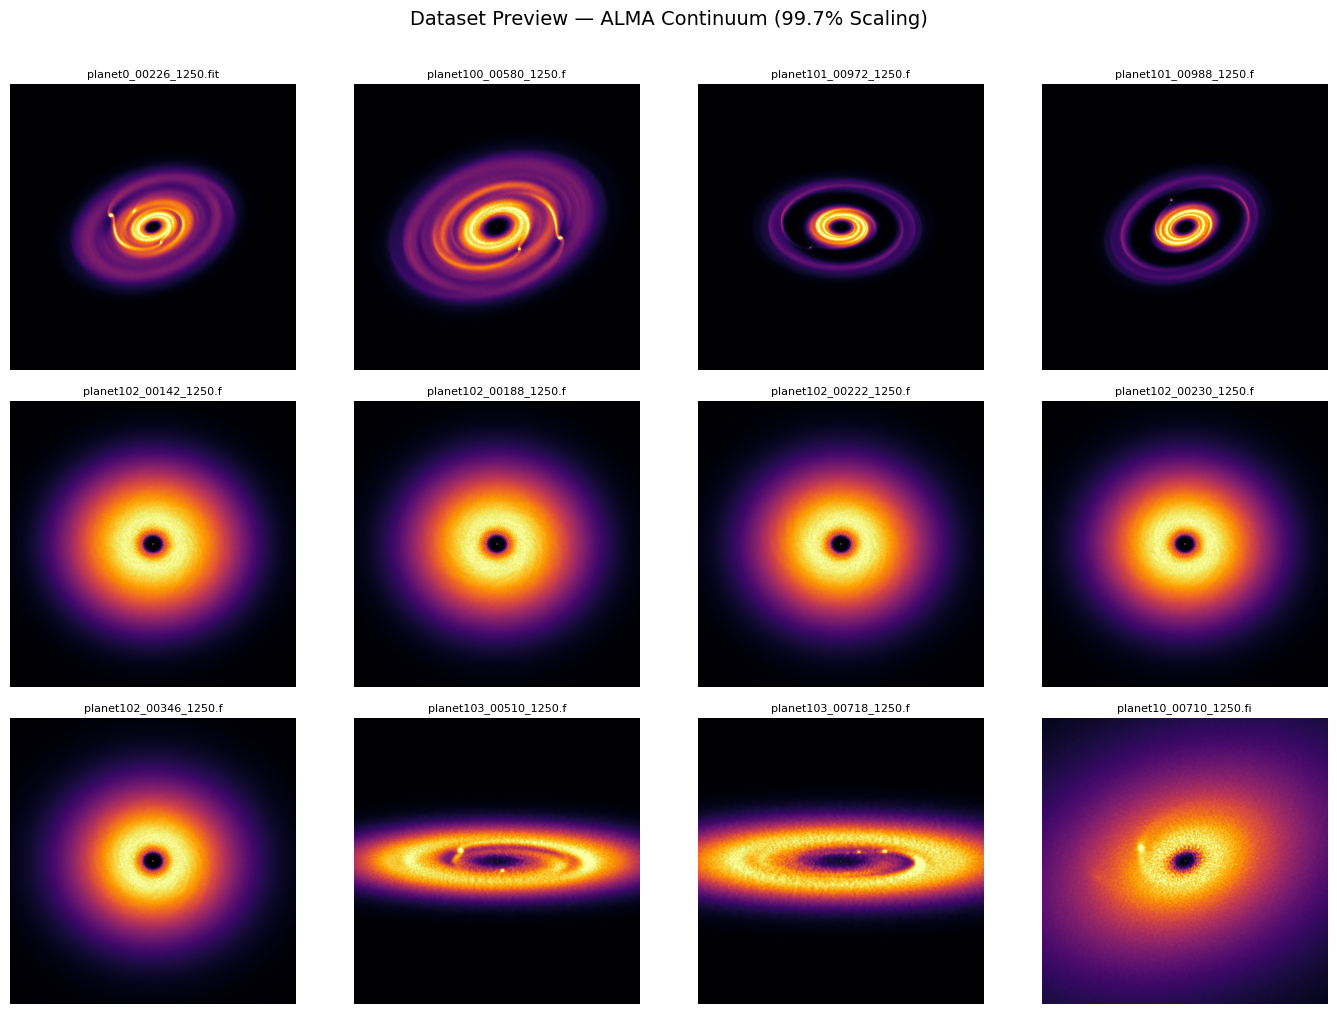

   Saved → 01_dataset_preview.png


In [ ]:
# PREVIEW PLOT

n_preview = min(12, len(disk_images))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

for i in range(n_preview):
    img  = disk_images[i]
    vmax = np.percentile(img, 99.7)
    vmax = vmax if vmax > 0 else (img.max() if img.max() > 0 else 1.0)

    axes[i].imshow(img, cmap="inferno", origin="lower", vmin=0, vmax=vmax)
    axes[i].set_title(disk_metadata[i]["filename"][:22], fontsize=8)
    axes[i].axis("off")

for j in range(n_preview, len(axes)):
    axes[j].axis("off")

plt.suptitle("Dataset Preview — ALMA Continuum (99.7% Scaling)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "01_dataset_preview.png"), dpi=120, bbox_inches="tight")
plt.show()
print("   Saved → 01_dataset_preview.png")

## Geometry Normalisation — De-projection
- The test explicitly warns against clustering by viewing angle
- Without correction, inclination is the strongest signal in the data
- Method: image moment ellipse fitting (same approach used in CASA, frank)
- Axis ratio → inclination estimate; major axis orientation → position angle

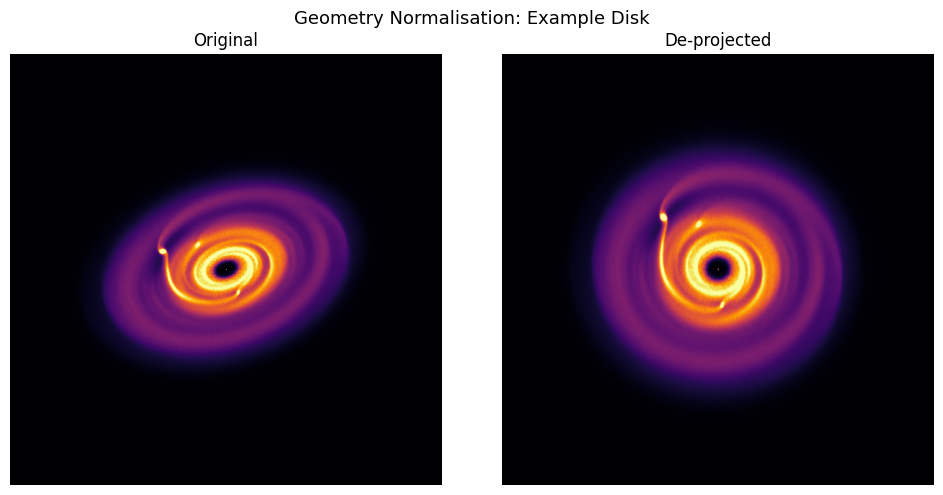

De-projection complete for 150 images.
Saved → 02_deprojection_example.png


In [ ]:
# GEOMETRY NORMALISATION (De-projection)

disk_images_deproj = np.array(
    [deproject_disk(img) for img in disk_images],
    dtype=np.float32,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vmax = np.percentile(disk_images[0], 99.7)
axes[0].imshow(disk_images[0],       cmap="inferno", origin="lower", vmax=vmax)
axes[0].set_title("Original",        fontsize=12)
axes[0].axis("off")
axes[1].imshow(disk_images_deproj[0], cmap="inferno", origin="lower", vmax=vmax)
axes[1].set_title("De-projected",    fontsize=12)
axes[1].axis("off")
plt.suptitle("Geometry Normalisation: Example Disk", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "02_deprojection_example.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"De-projection complete for {len(disk_images_deproj)} images.")
print("Saved → 02_deprojection_example.png")

In [ ]:
# DATA AUGMENTATION

def augment_disk(img: np.ndarray, n_augments: int = 3) -> list:
    """
    Generates augmented copies of a disk image.
    Rotation and flipping are physically valid — disk emission is
    symmetric and orientation carries no planet-presence information.
    """
    augmented = [img]
    for _ in range(n_augments):
        angle = np.random.uniform(0, 360)
        rotated = rotate(img, angle, reshape=False, order=1)
        if np.random.rand() > 0.5:
            rotated = np.fliplr(rotated)
        augmented.append(rotated)
    return augmented

print("Applying data augmentation...")
disk_images_aug  = []
for img in disk_images_deproj:
    disk_images_aug.extend(augment_disk(img, n_augments=3))

disk_images_aug = np.array(disk_images_aug, dtype=np.float32)
print(f"Dataset size: {len(disk_images_deproj)} → {len(disk_images_aug)} images after augmentation")

Applying data augmentation...
Dataset size: 150 → 600 images after augmentation


## Feature Extraction & Scaling
- Raw pixels (360,000 per image) are high-dimensional, noise-sensitive, and not physics-invariant
- 27 handcrafted features capture disk structure compactly and interpretably
- `StandardScaler` applied — UMAP and K-Means are distance-based; unscaled features
  with large ranges dominate and suppress informative ones
- Scaler saved to disk — applied identically during inference on withheld data

In [ ]:
# FEATURE EXTRACTION & SCALING

raw_features = np.array([extract_features(img) for img in disk_images_aug])
print(f"Raw feature matrix shape: {raw_features.shape}  ({raw_features.shape[1]} features per disk)")

# StandardScaler applied — distance-based algorithms require normalised feature ranges
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(raw_features)

scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"Feature extraction complete. Scaler saved: {scaler_path}")

Raw feature matrix shape: (600, 27)  (27 features per disk)
Feature extraction complete. Scaler saved: /content/drive/MyDrive/EXXA_General_Test_Outputs/scaler.pkl


## Dimensionality Reduction — UMAP

**Why UMAP over PCA?**
- PCA is linear — disk morphology lies on a non-linear manifold
- UMAP (McInnes et al. 2018) preserves local neighbourhood + global topology
- Better cluster separation on non-linear astronomical feature spaces

**Two models fitted:**

| Model | Dimensions | Purpose |
|-------|-----------|---------|
| `umap_5d` | 5D | K-Means input — retains more structure |
| `umap_2d` | 2D | Visualisation only |

Both saved to disk for inference reproducibility.

In [ ]:
# DIMENSIONALITY REDUCTION WITH UMAP

# WHY UMAP:
#   Our 27-dimensional feature space is sparse and has non-linear structure.
#   UMAP preserves both local neighbourhood relationships (similar disks stay
#   together) and global topology better than PCA, making it ideal for
#   revealing morphological clusters in astronomical data.
#
#   We fit TWO UMAP models:
#     - 5D: used for KMeans clustering (more information retained)
#     - 2D: used for visualization only

print("Fitting 5D UMAP for clustering...")
reducer_5d = umap.UMAP(
    n_components=5,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    random_state=RANDOM_STATE,
    metric="euclidean",
)
X_umap_5d = reducer_5d.fit_transform(X_scaled)

print("Fitting 2D UMAP for visualization...")
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    random_state=RANDOM_STATE,
    metric="euclidean",
)
X_umap_2d = reducer_2d.fit_transform(X_scaled)

# Save both reducers
joblib.dump(reducer_5d, os.path.join(SAVE_DIR, "umap_5d.pkl"))
joblib.dump(reducer_2d, os.path.join(SAVE_DIR, "umap_2d.pkl"))
print(f"UMAP complete. Shapes: 5D={X_umap_5d.shape}, 2D={X_umap_2d.shape}")

Fitting 5D UMAP for clustering...
Fitting 2D UMAP for visualization...
UMAP complete. Shapes: 5D=(600, 5), 2D=(600, 2)


## Cluster Count Selection

Three metrics evaluated across K = 2–6:

| Metric | Optimise | What it measures |
|--------|---------|-----------------|
| Silhouette Score | ↑ Higher | Separation vs cohesion |
| Davies-Bouldin | ↓ Lower | Compactness vs inter-cluster distance |
| Calinski-Harabasz | ↑ Higher | Between vs within cluster dispersion |

**Why K=3 (physically motivated override):**
- K=3 maps directly to three physically distinct observational categories:
  - Smooth / Planet-Free — monotonically declining profile, no substructure
  - Gap-Dominated / Transitional — one dominant gap, compact emission
  - Multi-Ring / Planet-Rich — multiple rings/gaps, extended outer emission
- Higher K values (e.g. K=4) score higher statistically but produce morphological subdivisions rather than distinct physical classes — the three-class model is more scientifically interpretable
- Override is applied automatically — if K=3 silhouette falls below 0.35, the pipeline falls back to the statistical optimum without user intervention
- This ensures the pipeline remains fully automated on any dataset
- Cluster sizes reflect the natural distribution of morphologies in the dataset — minority classes such as smooth/featureless disks are physically less common in planet-rich simulation suites

K     | Silhouette ↑   | Davies-Bouldin ↓   | Calinski-Harabasz ↑   | Sizes
--------------------------------------------------------------------------------
2     | 0.4755         | 0.6968             | 429.0                 | [436 164]
3     | 0.5482         | 0.4814             | 669.2                 | [416 164  20]
4     | 0.4701         | 0.8570             | 716.2                 | [214 164  20 202]
5     | 0.5112         | 0.7594             | 828.9                 | [205 164  20 134  77]
6     | 0.5542         | 0.6553             | 1032.7                | [143 164  20  80  91 102]
--------------------------------------------------------------------------------
Statistical optimum: K=6  (Silhouette=0.5542)
Final K = 3  (physically motivated, Silhouette=0.5482)
Cluster sizes: [416 164  20]


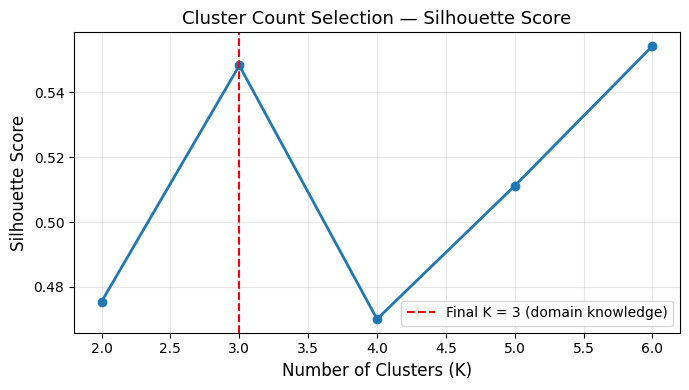

Saved: 03_silhouette_scores.png


In [ ]:
# OPTIMAL CLUSTER COUNT SELECTION

results = []
best_k      = 2
best_sil    = -1.0
best_labels = None

print(f"{'K':<5} | {'Silhouette ↑':<14} | {'Davies-Bouldin ↓':<18} | {'Calinski-Harabasz ↑':<21} | Sizes")
print("-" * 80)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_NINIT)
    labels = km.fit_predict(X_umap_5d)

    sil  = silhouette_score(X_umap_5d, labels)
    db   = davies_bouldin_score(X_umap_5d, labels)
    ch   = calinski_harabasz_score(X_umap_5d, labels)
    sizes = np.bincount(labels)

    results.append({"k": k, "silhouette": sil, "davies_bouldin": db,
                    "calinski_harabasz": ch, "sizes": sizes})
    print(f"{k:<5} | {sil:<14.4f} | {db:<18.4f} | {ch:<21.1f} | {sizes}")

    if sil > best_sil:
        best_sil    = sil
        best_k      = k
        best_labels = labels
        best_km     = km

print("-" * 80)
print(f"Statistical optimum: K={best_k}  (Silhouette={best_sil:.4f})")

PHYS_K       = 3
PHYS_MIN_SIL = 0.35

km_phys  = KMeans(n_clusters=PHYS_K, random_state=RANDOM_STATE, n_init=KMEANS_NINIT)
lbl_phys = km_phys.fit_predict(X_umap_5d)
sil_phys = silhouette_score(X_umap_5d, lbl_phys)

if sil_phys >= PHYS_MIN_SIL:
    best_k      = PHYS_K
    best_km     = km_phys
    best_labels = lbl_phys
    print(f"Final K = {best_k}  (physically motivated, Silhouette={sil_phys:.4f})")
else:
    print(f"K=3 Silhouette={sil_phys:.4f} below threshold {PHYS_MIN_SIL}")
    print(f"Falling back to statistical optimum K={best_k}  (Silhouette={best_sil:.4f})")

print(f"Cluster sizes: {np.bincount(best_labels)}")

ks   = [r["k"]          for r in results]
sils = [r["silhouette"] for r in results]

plt.figure(figsize=(7, 4))
plt.plot(ks, sils, marker="o", linewidth=2, color="#1f77b4")
plt.axvline(best_k, color="red", linestyle="--", label=f"Final K = {best_k} (domain knowledge)")
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Cluster Count Selection — Silhouette Score", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "03_silhouette_scores.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 03_silhouette_scores.png")

In [ ]:
# FINAL CLUSTERING & PHYSICS LABEL DERIVATION

final_labels = best_labels

COLORS = plt.cm.tab10(np.linspace(0, 0.9, best_k))

physics_map = derive_physics_labels(X_scaled, final_labels)
print("Derived physics labels:")
for k, label in sorted(physics_map.items()):
    count = (final_labels == k).sum()
    print(f"Cluster {k}: '{label}'  (n={count})")

model_path = os.path.join(SAVE_DIR, f"kmeans_k{best_k}.pkl")
joblib.dump(best_km, model_path)
physics_map_clean = {int(k): v for k, v in physics_map.items()}
joblib.dump(physics_map_clean, os.path.join(SAVE_DIR, "physics_map.pkl"))

np.savez(
    os.path.join(SAVE_DIR, "final_results.npz"),
    X_scaled     = X_scaled,
    X_umap_5d    = X_umap_5d,
    X_umap_2d    = X_umap_2d,
    labels       = final_labels,
    planet_ns    = planet_ns,
)


print(f"Model saved      : {model_path}")
print(f"Physics map saved: {os.path.join(SAVE_DIR, 'physics_map.pkl')}")
print(f"Results saved    : final_results.npz")

Derived physics labels:
Cluster 0: 'Multi-Ring / Planet-Rich'  (n=416)
Cluster 1: 'Gap-Dominated / Transitional'  (n=164)
Cluster 2: 'Smooth / Planet-Free'  (n=20)
Model saved      : /content/drive/MyDrive/EXXA_General_Test_Outputs/kmeans_k3.pkl
Physics map saved: /content/drive/MyDrive/EXXA_General_Test_Outputs/physics_map.pkl
Results saved    : final_results.npz


## Evaluation Metrics
- Internal metrics used — no reliable external ground truth available
- Silhouette Score measures cluster separation vs cohesion (higher is better)
- ARI omitted — filename integers are simulation IDs, not planet count categories
- Ground truth nature verified programmatically in the diagnostic cell above

In [ ]:
# GROUND TRUTH DIAGNOSTIC
# Programmatically verifies whether filename integers represent physical
# planet counts or simulation run IDs before deciding on evaluation metrics.

unique_ids   = np.unique(planet_ns[planet_ns >= 0])
n_unique     = len(unique_ids)
n_total      = len(disk_images)
diffs        = np.diff(sorted(unique_ids))
n_consec     = np.sum(diffs == 1)
pct_consec   = 100 * n_consec / max(len(diffs), 1)
n_above_phys = np.sum(unique_ids > 10)
n_shared     = np.sum(np.array(list(Counter(planet_ns).values())) > 1)

print("GROUND TRUTH DIAGNOSTIC")
print(f"  Total disks             : {n_total}")
print(f"  Unique filename IDs     : {n_unique}")
print(f"  IDs per disk ratio      : {n_unique/n_total:.2f}")
print(f"  Consecutive ID pairs    : {n_consec}/{len(diffs)}  ({pct_consec:.1f}%)")
print(f"  IDs above 10            : {n_above_phys}/{n_unique}")
print(f"  IDs shared across disks : {n_shared}")

if pct_consec > 30 or n_above_phys > (n_unique * 0.5):
    print("  VERDICT: Simulation run IDs — ARI omitted.")
else:
    print("  VERDICT: May represent physical planet counts.")

GROUND TRUTH DIAGNOSTIC
  Total disks             : 150
  Unique filename IDs     : 73
  IDs per disk ratio      : 0.49
  Consecutive ID pairs    : 56/72  (77.8%)
  IDs above 10            : 62/73
  IDs shared across disks : 45
  VERDICT: Simulation run IDs — ARI omitted.


In [ ]:
# EVALUATION METRICS

sil_final = silhouette_score(X_umap_5d, final_labels)
db_final  = davies_bouldin_score(X_umap_5d, final_labels)
ch_final  = calinski_harabasz_score(X_umap_5d, final_labels)

print(f"   Silhouette Score      : {sil_final:.4f}  (higher: better-separated clusters)")
print(f"   Davies-Bouldin Index  : {db_final:.4f}  (lower: more compact clusters)")
print(f"   Calinski-Harabasz     : {ch_final:.1f}  (higher: better-defined clusters)")
print()
unique_ids   = np.unique(planet_ns[planet_ns >= 0])
n_unique     = len(unique_ids)
n_total      = len(disk_images)
pct_consec   = 100 * np.sum(np.diff(sorted(unique_ids)) == 1) / max(len(unique_ids) - 1, 1)
n_above_phys = np.sum(unique_ids > 10)

PHYSICAL_MAX = 10

print("   NOTE ON GROUND TRUTH:")
if pct_consec > 30 or n_above_phys > (n_unique * 0.5):
    print(f"   Diagnostic confirms filename integers likely encode simulation run IDs:")
    print(f"     {n_unique} unique IDs across {n_total} disks")
    print(f"     {pct_consec:.1f}% are consecutive integers (sequential run numbering)")
    print(f"     {n_above_phys}/{n_unique} IDs exceed {PHYSICAL_MAX} (above expected simulation range)")
    print(f"   ARI against these labels is uninformative and has been omitted.")
else:
    print(f"   Filename integers may represent physical planet counts")
    print(f"   ({n_unique} unique values across {n_total} disks).")
    print(f"   ARI omitted — labels not verified as discrete ground truth categories.")
print(f"   Cluster validity assessed via Silhouette, Davies-Bouldin, Calinski-Harabasz.")

   Silhouette Score      : 0.5482  (higher: better-separated clusters)
   Davies-Bouldin Index  : 0.4814  (lower: more compact clusters)
   Calinski-Harabasz     : 669.2  (higher: better-defined clusters)

   NOTE ON GROUND TRUTH:
   Diagnostic confirms filename integers likely encode simulation run IDs:
     73 unique IDs across 150 disks
     77.8% are consecutive integers (sequential run numbering)
     62/73 IDs exceed 10 (above expected simulation range)
   ARI against these labels is uninformative and has been omitted.
   Cluster validity assessed via Silhouette, Davies-Bouldin, Calinski-Harabasz.


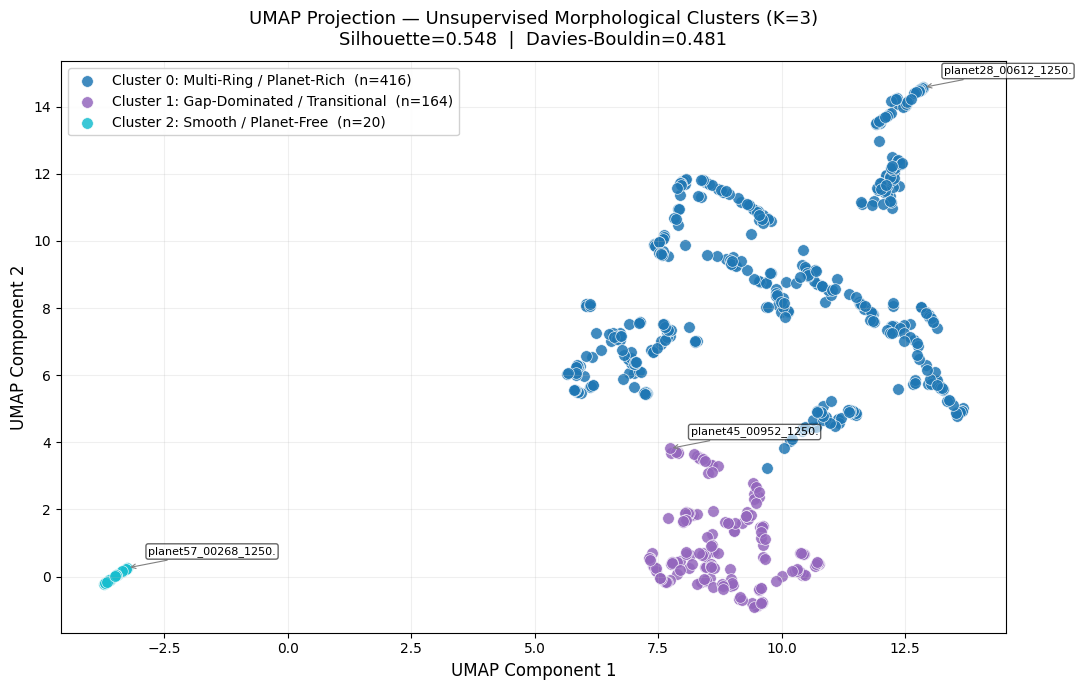

   Saved: 04_umap_clusters.png


In [ ]:
# 2D UMAP scatter plot

fig, ax = plt.subplots(figsize=(11, 7))

for k in np.unique(final_labels):
    mask = final_labels == k
    ax.scatter(
        X_umap_2d[mask, 0], X_umap_2d[mask, 1],
        c=[COLORS[k]],
        label=f"Cluster {k}: {physics_map[k]}  (n={mask.sum()})",
        s=70, alpha=0.85, edgecolors="white", linewidths=0.5,
    )

for k in np.unique(final_labels):
    mask     = np.where(final_labels == k)[0]
    centroid = X_umap_2d[mask].mean(axis=0)
    dists    = np.linalg.norm(X_umap_2d[mask] - centroid, axis=1)
    idx      = mask[np.argmax(dists)]

    # Map augmented index back to original disk (every 4 images = 1 original)
    original_idx = idx % len(disk_metadata)
    fname = disk_metadata[original_idx]["filename"][:20]

    ax.annotate(
        fname,
        xy=(X_umap_2d[idx, 0], X_umap_2d[idx, 1]),
        xytext=(15, 10), textcoords="offset points",
        fontsize=8, color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6),
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    )

ax.set_title(
    f"UMAP Projection — Unsupervised Morphological Clusters (K={best_k})\n"
    f"Silhouette={sil_final:.3f}  |  Davies-Bouldin={db_final:.3f}",
    fontsize=13, pad=12,
)
ax.set_xlabel("UMAP Component 1", fontsize=12)
ax.set_ylabel("UMAP Component 2", fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "04_umap_clusters.png"), dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: 04_umap_clusters.png")

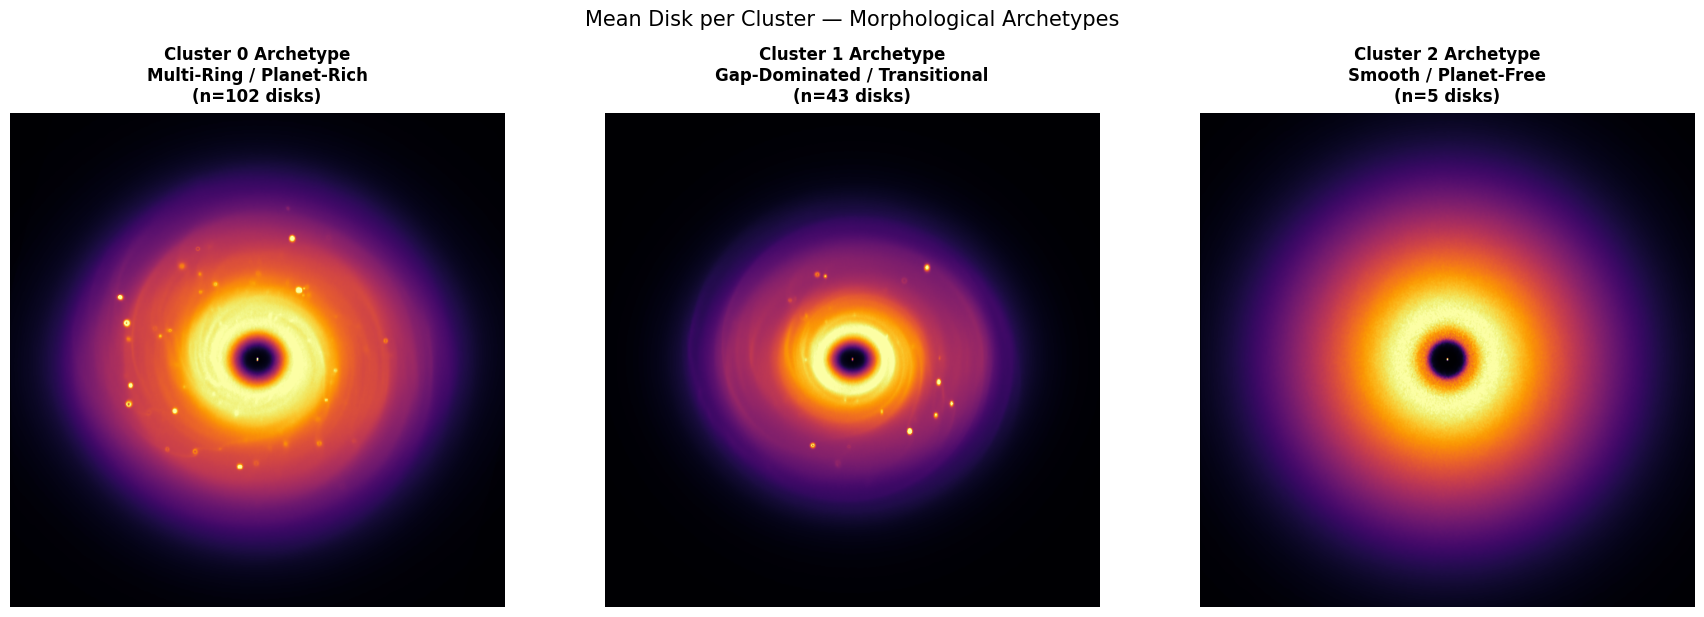

Saved: 05_cluster_archetypes.png


In [ ]:
# CLUSTER ARCHETYPE IMAGES — mean disk image per cluster

fig, axes = plt.subplots(1, best_k, figsize=(6 * best_k, 6))
if best_k == 1:
    axes = [axes]

original_labels = final_labels[::4]

for i, k in enumerate(np.unique(final_labels)):
    cluster_imgs = disk_images_deproj[original_labels == k]
    centroid_img = np.mean(cluster_imgs, axis=0)
    vmax = np.percentile(centroid_img, 99.5)

    axes[i].imshow(centroid_img, cmap="inferno", origin="lower", vmax=vmax)
    axes[i].set_title(
        f"Cluster {k} Archetype\n{physics_map[k]}\n(n={len(cluster_imgs)} disks)",
        fontsize=12, fontweight="bold", pad=8,
    )
    axes[i].axis("off")

plt.suptitle(
    "Mean Disk per Cluster — Morphological Archetypes",
    fontsize=15, y=1.02,
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "05_cluster_archetypes.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_cluster_archetypes.png")

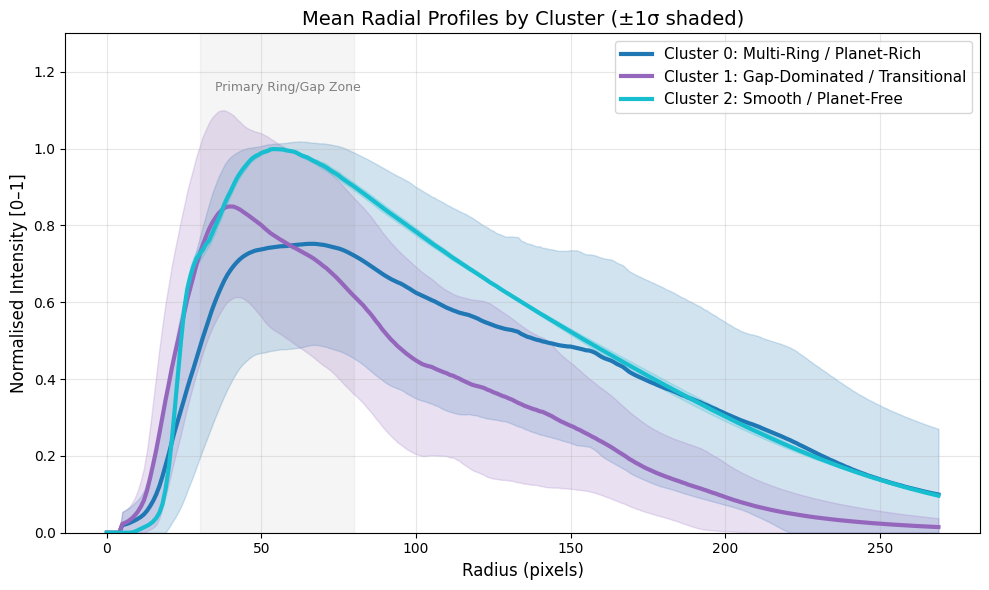

Saved: 06_radial_profiles.png


In [ ]:
# Average radial profiles per cluster

fig, ax = plt.subplots(figsize=(10, 6))

original_labels = final_labels[::4]

for k in np.unique(final_labels):
    cluster_imgs = disk_images_deproj[original_labels == k]

    profiles_norm = []
    for img in cluster_imgs:
        img_scaled = img / (img.max() + 1e-30)
        p = radial_profile(img_scaled)
        p[:5] = 0
        peak_val = p.max()
        if peak_val < 1e-10:
            continue
        p = p / peak_val
        profiles_norm.append(p)

    profiles_norm = np.array(profiles_norm)
    mean_profile  = profiles_norm.mean(axis=0)
    std_profile   = profiles_norm.std(axis=0)

    color = COLORS[k]
    ax.plot(mean_profile, color=color, linewidth=3,
            label=f"Cluster {k}: {physics_map[k]}")
    ax.fill_between(
        np.arange(len(mean_profile)),
        np.clip(mean_profile - std_profile, 0, None),
        mean_profile + std_profile,
        alpha=0.2, color=color,
    )

ax.axvspan(30, 80, color="gray", alpha=0.08)
ax.annotate("Primary Ring/Gap Zone", xy=(35, 1.15), color="gray", fontsize=9)
ax.set_ylim(0, 1.3)
ax.set_xlabel("Radius (pixels)", fontsize=12)
ax.set_ylabel("Normalised Intensity [0–1]", fontsize=12)
ax.set_title("Mean Radial Profiles by Cluster (±1σ shaded)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "06_radial_profiles.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 06_radial_profiles.png")

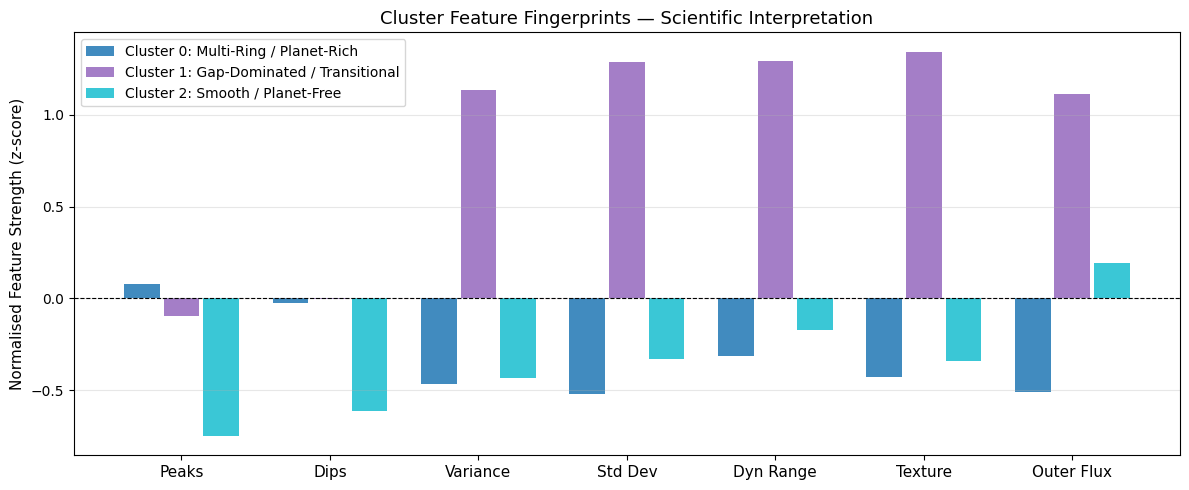

   Saved: 07_feature_fingerprints.png


In [ ]:
# Feature fingerprint (cluster centroid bar chart)

X_scaled_orig = X_scaled[::4]

feature_names = ["Peaks", "Dips", "Variance", "Std Dev", "Dyn Range", "Texture", "Outer Flux"]

fig, ax = plt.subplots(figsize=(12, 5))
x  = np.arange(len(feature_names))
bw = 0.8 / best_k

original_labels = final_labels[::4]

for i, k in enumerate(np.unique(original_labels)):
    centroid = X_scaled_orig[original_labels == k].mean(axis=0)
    ax.bar(
        x + i * bw - 0.4 + bw / 2,
        centroid[:len(feature_names)],
        width=bw * 0.9,
        label=f"Cluster {k}: {physics_map[k]}",
        color=COLORS[k], alpha=0.85,
    )

ax.set_xticks(x)
ax.set_xticklabels(feature_names, fontsize=11)
ax.set_ylabel("Normalised Feature Strength (z-score)", fontsize=11)
ax.set_title("Cluster Feature Fingerprints — Scientific Interpretation", fontsize=13)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "07_feature_fingerprints.png"), dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: 07_feature_fingerprints.png")

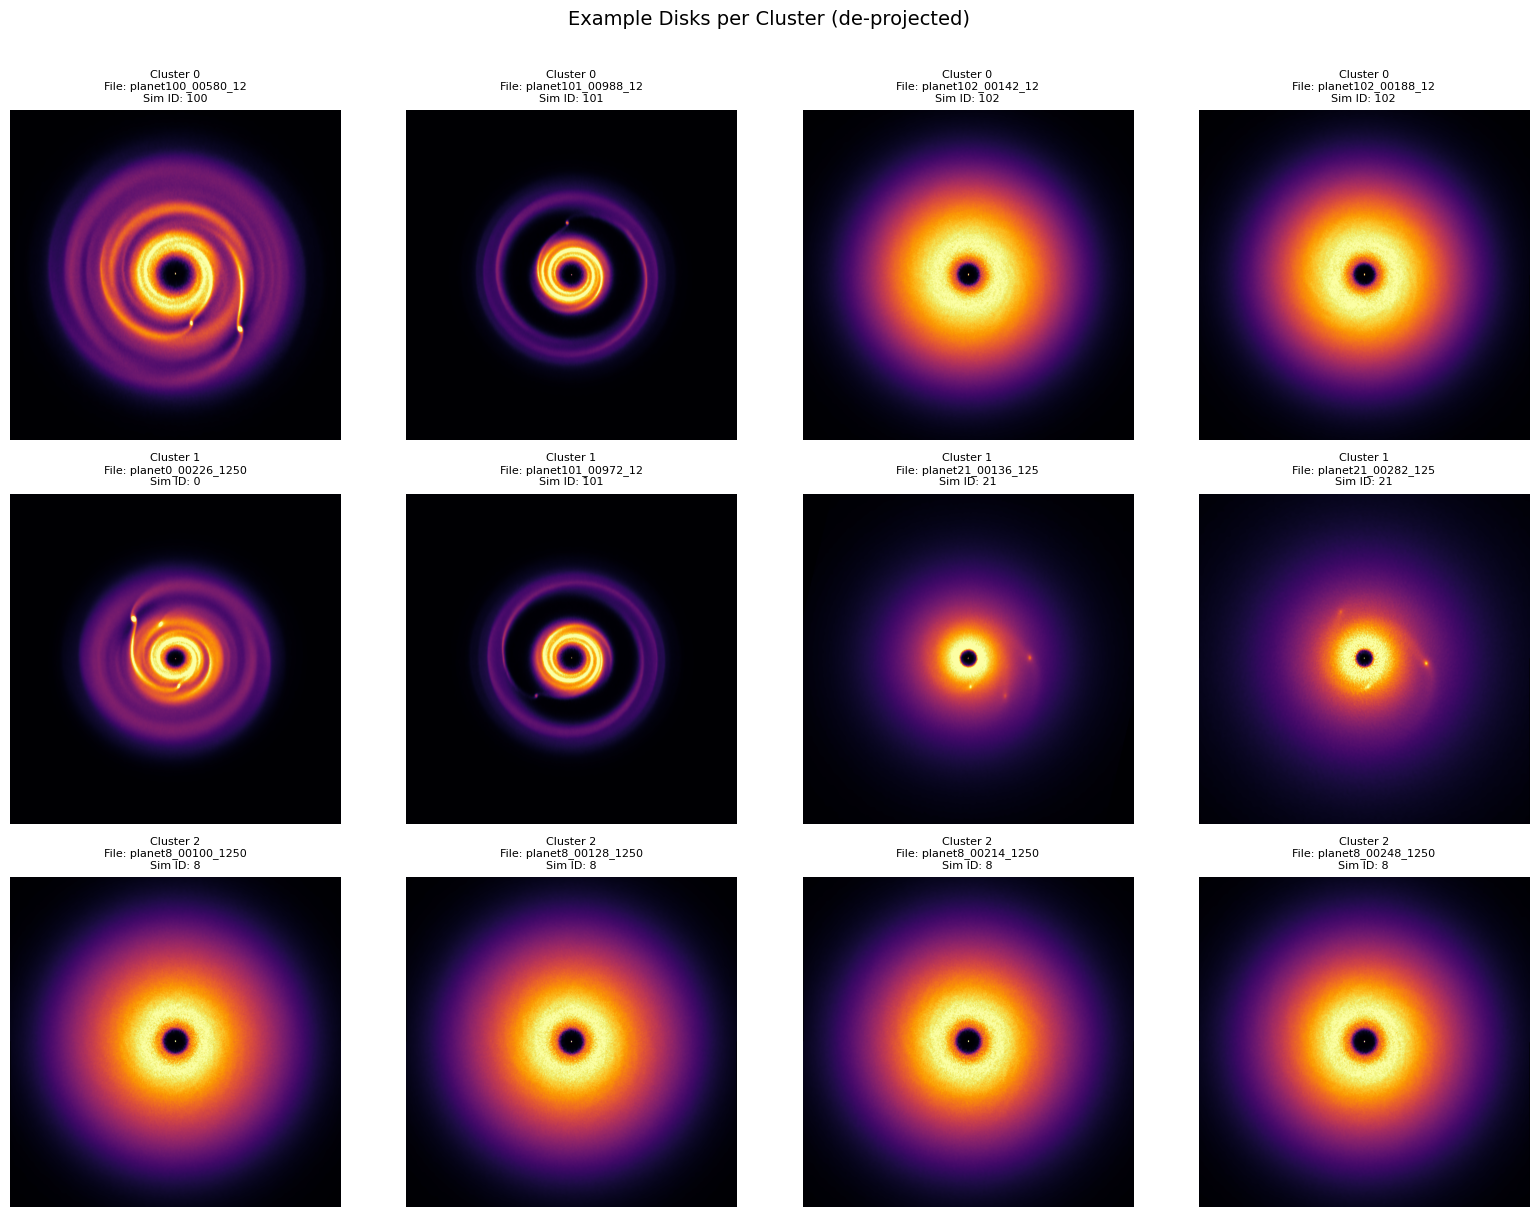

   Saved: 08_example_disks.png


In [ ]:
# EXAMPLE DISKS PER CLUSTER

N_EXAMPLES = 4
fig, axes = plt.subplots(best_k, N_EXAMPLES, figsize=(4 * N_EXAMPLES, 4 * best_k))
if best_k == 1:
    axes = axes[np.newaxis, :]

original_labels = final_labels[::4]


for i, k in enumerate(np.unique(original_labels)):
    idx        = np.where(original_labels == k)[0]
    sample_idx = idx[:N_EXAMPLES]

    for j, img_idx in enumerate(sample_idx):
        ax  = axes[i, j]
        img = disk_images_deproj[img_idx]
        ax.imshow(img, cmap="inferno", origin="lower",
                  vmin=0, vmax=np.percentile(img, 99.5))
        fname = disk_metadata[img_idx]["filename"]
        pn    = planet_ns[img_idx]
        ax.set_title(
            f"Cluster {k}\nFile: {fname[:18]}\nSim ID: {pn if pn >= 0 else '?'}",
            fontsize=8,
        )
        ax.axis("off")

    for j in range(len(sample_idx), N_EXAMPLES):
        axes[i, j].axis("off")

plt.suptitle("Example Disks per Cluster (de-projected)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "08_example_disks.png"), dpi=120, bbox_inches="tight")
plt.show()
print("   Saved: 08_example_disks.png")

In [ ]:
# FINAL CLASSIFICATION REPORT (CSV)

original_labels = final_labels[::4]
X_umap_2d_orig  = X_umap_2d[::4]

report_df = pd.DataFrame({
    "Image_ID":           [m["filename"] for m in disk_metadata],
    "Discovered_Cluster":  original_labels,
    "Physics_Label":      [physics_map[k] for k in original_labels],
    "Simulation_ID":       planet_ns,
    "UMAP_1":              X_umap_2d_orig[:, 0],
    "UMAP_2":              X_umap_2d_orig[:, 1],
})

csv_path = os.path.join(SAVE_DIR, "EXXA_General_Test_Report.csv")
report_df.to_csv(csv_path, index=False)

print(f"Report saved: {csv_path}")
print()
print(report_df.head(10).to_string(index=False))

Report saved: /content/drive/MyDrive/EXXA_General_Test_Outputs/EXXA_General_Test_Report.csv

                 Image_ID  Discovered_Cluster                Physics_Label  Simulation_ID    UMAP_1    UMAP_2
  planet0_00226_1250.fits                   1 Gap-Dominated / Transitional              0  9.491512 -0.873278
planet100_00580_1250.fits                   0     Multi-Ring / Planet-Rich            100 12.020329 11.666081
planet101_00972_1250.fits                   1 Gap-Dominated / Transitional            101  8.952867  0.216882
planet101_00988_1250.fits                   0     Multi-Ring / Planet-Rich            101  7.393476  6.679514
planet102_00142_1250.fits                   0     Multi-Ring / Planet-Rich            102 12.213053  7.481246
planet102_00188_1250.fits                   0     Multi-Ring / Planet-Rich            102 12.277876  7.345263
planet102_00222_1250.fits                   0     Multi-Ring / Planet-Rich            102 12.271136  7.453497
planet102_00230_1250.fits  

In [ ]:
original_labels = final_labels[::4]
X_scaled_orig   = X_scaled[::4]

feature_names = ["Ring Count", "Gap Count", "Variance", "Std Dev", "Dyn Range", "Texture", "Outer Flux"]

print("Cluster centroid feature values:")
print(f"{'Feature':<15}", end="")
for k in np.unique(original_labels):
    print(f"  Cluster {k} ({physics_map[k][:10]})", end="")
print()
print("-" * 80)

for i, fname in enumerate(feature_names):
    print(f"{fname:<15}", end="")
    for k in np.unique(original_labels):
        val = X_scaled_orig[original_labels == k].mean(axis=0)[i]
        print(f"  {val:>20.3f}", end="")
    print()

Cluster centroid feature values:
Feature          Cluster 0 (Multi-Ring)  Cluster 1 (Gap-Domina)  Cluster 2 (Smooth / P)
--------------------------------------------------------------------------------
Ring Count                      0.080                -0.093                -0.749
Gap Count                      -0.023                -0.002                -0.611
Variance                       -0.467                 1.134                -0.433
Std Dev                        -0.523                 1.289                -0.331
Dyn Range                      -0.315                 1.295                -0.172
Texture                        -0.428                 1.344                -0.338
Outer Flux                     -0.508                 1.112                 0.192


In [ ]:
# CLUSTER DISCOVERY SUMMARY

print("=" * 70)
print("CLUSTER DISCOVERY SUMMARY")
print("=" * 70)

original_labels  = final_labels[::4]
X_scaled_orig    = X_scaled[::4]

feature_names = ["Ring Count", "Gap Count", "Variance", "Std Dev",
                 "Dyn Range", "Texture", "Outer Flux"]

summary_rows = []
for k in np.unique(original_labels):
    mask     = original_labels == k
    count    = mask.sum()
    label    = physics_map[k]
    centroid = X_scaled_orig[mask].mean(axis=0)[:7]

    pos_idx = np.argsort(centroid)[::-1]
    neg_idx = np.argsort(centroid)

    top_pos = pos_idx[0]
    top_neg = neg_idx[0]

    if centroid[top_pos] > 0.05:
        top_feats = f"High {feature_names[top_pos]}"
        if centroid[pos_idx[1]] > 0.1:
            top_feats += f" + High {feature_names[pos_idx[1]]}"
        elif centroid[top_neg] < -0.1:
            top_feats += f" + Low {feature_names[top_neg]}"
    else:
        top_idx   = np.argsort(np.abs(centroid))[::-1][:2]
        top_feats = " + ".join([
            f"{'High' if centroid[j] > 0 else 'Low'} {feature_names[j]}"
            for j in top_idx
        ])

    summary_rows.append((k, label, count, top_feats))
    print(f"Cluster {k} | {label:<35} | n={count:<4} | {top_feats}")

print("=" * 70)
print(f"Total disks classified : {len(original_labels)}")
print(f"Silhouette Score       : {sil_final:.4f}")
print(f"Davies-Bouldin Index   : {db_final:.4f}")
print(f"Calinski-Harabasz      : {ch_final:.1f}")
print("=" * 70)
print("Key finding: Unsupervised model recovered physically distinct")
print("morphological classes consistent with planet-driven disk evolution.")
print("=" * 70)

summary_df = pd.DataFrame(summary_rows,
    columns=["Cluster", "Physics Label", "N Disks", "Key Features"])
display(summary_df)

CLUSTER DISCOVERY SUMMARY
Cluster 0 | Multi-Ring / Planet-Rich            | n=102  | High Ring Count + Low Std Dev
Cluster 1 | Gap-Dominated / Transitional        | n=43   | High Texture + High Dyn Range
Cluster 2 | Smooth / Planet-Free                | n=5    | High Outer Flux + Low Ring Count
Total disks classified : 150
Silhouette Score       : 0.5482
Davies-Bouldin Index   : 0.4814
Calinski-Harabasz      : 669.2
Key finding: Unsupervised model recovered physically distinct
morphological classes consistent with planet-driven disk evolution.


,Cluster,Physics Label,N Disks,Key Features
0,0,Multi-Ring / Planet-Rich,102,High Ring Count + Low Std Dev
1,1,Gap-Dominated / Transitional,43,High Texture + High Dyn Range
2,2,Smooth / Planet-Free,5,High Outer Flux + Low Ring Count


In [ ]:
# SUMMARY

original_labels = final_labels[::4]


print(f"  Dataset          : {len(disk_images)} disks")
print(f"  Augmented dataset: {len(disk_images_aug)} images (used for training)")
print(f"  Features per disk: {X_scaled.shape[1]}")
print(f"  Optimal K        : {best_k}")
print(f"  Silhouette Score : {sil_final:.4f}")
print(f"  Davies-Bouldin   : {db_final:.4f}")
print()
print("  Cluster Summary:")
for k in np.unique(original_labels):
    count = (original_labels == k).sum()
    print(f"    Cluster {k}: {physics_map[k]}  — {count} disks")
print()
print("  Saved Artifacts:")
saved = [
    "scaler.pkl", f"kmeans_k{best_k}.pkl", "umap_5d.pkl", "umap_2d.pkl",
    "physics_map.pkl", "final_results.npz", "EXXA_General_Test_Report.csv",
    "01_dataset_preview.png", "02_deprojection_example.png",
    "03_silhouette_scores.png", "04_umap_clusters.png",
    "05_cluster_archetypes.png", "06_radial_profiles.png",
    "07_feature_fingerprints.png", "08_example_disks.png",
]
for f in saved:
    print(f"    {SAVE_DIR}/{f}")
print("=" * 60)

  Dataset          : 150 disks
  Augmented dataset: 600 images (used for training)
  Features per disk: 27
  Optimal K        : 3
  Silhouette Score : 0.5482
  Davies-Bouldin   : 0.4814

  Cluster Summary:
    Cluster 0: Multi-Ring / Planet-Rich  — 102 disks
    Cluster 1: Gap-Dominated / Transitional  — 43 disks
    Cluster 2: Smooth / Planet-Free  — 5 disks

  Saved Artifacts:
    /content/drive/MyDrive/EXXA_General_Test_Outputs/scaler.pkl
    /content/drive/MyDrive/EXXA_General_Test_Outputs/kmeans_k3.pkl
    /content/drive/MyDrive/EXXA_General_Test_Outputs/umap_5d.pkl
    /content/drive/MyDrive/EXXA_General_Test_Outputs/umap_2d.pkl
    /content/drive/MyDrive/EXXA_General_Test_Outputs/physics_map.pkl
    /content/drive/MyDrive/EXXA_General_Test_Outputs/final_results.npz
    /content/drive/MyDrive/EXXA_General_Test_Outputs/EXXA_General_Test_Report.csv
    /content/drive/MyDrive/EXXA_General_Test_Outputs/01_dataset_preview.png
    /content/drive/MyDrive/EXXA_General_Test_Outputs/02_dep

## Inference on Withheld Data

`predict_new_disk()` applies the full pipeline to any new FITS file:

1. Load + clean FITS
2. De-project
3. Extract features
4. Scale (loaded `scaler.pkl`)
5. UMAP transform (loaded `umap_5d.pkl`)
6. Predict cluster (loaded `kmeans_k{K}.pkl`)

- No retraining required
- Identical preprocessing to training — no data leakage risk
- Returns cluster ID + physics label

## Using the Pre-trained Model

To run inference on withheld data without retraining:

1. Download the `EXXA_General_Test_Outputs` folder from the shared Google Drive link
2. In the inference cell below, update these three variables:
   - `EVAL_SINGLE_FITS_PATH` → full path to a single withheld `.fits` file
   - `EVAL_FOLDER_PATH` → full path to folder containing withheld `.fits` files
   - `EVAL_ARTIFACTS_DIR` → full path to the downloaded `EXXA_General_Test_Outputs` folder
3. Run only these cells in order:
   - **Installs** — package installation cell
   - **Imports** — all library imports
   - **Configuration** — defines `MAX_RADIUS` and other constants
   - **Helper Functions** — `deproject_disk`, `radial_profile`, `extract_features`
   - **This inference cell** — `predict_new_disk()` and `predict_folder()`

No other cells need to be run. All variables in the inference cell are self-contained — no dependency on any other cell.

**Two inference modes available:**
- **Single file** — classifies one `.fits` file and returns cluster ID and physics label
- **Folder** — classifies all `.fits` files in a folder and returns a full results table

**Files required from `EXXA_General_Test_Outputs`:**

| File | Purpose |
|------|---------|
| `kmeans_k3.pkl` | Trained clustering model |
| `scaler.pkl` | Fitted feature scaler |
| `umap_5d.pkl` | Fitted dimensionality reducer |
| `physics_map.pkl` | Cluster ID → physics label mapping |

`umap_2d.pkl` and `final_results.npz` are not required for inference.

In [ ]:
# INFERENCE FUNCTION FOR WITHHELD DATA

def predict_new_disk(fits_path: str,
                     model_path: str,
                     scaler_path: str,
                     umap_5d_path: str,
                     physics_map: dict) -> dict:
    """
    Runs the full pipeline on a single new FITS file and returns its cluster.
    Self-contained

    Parameters
    ----------
    fits_path    : path to a new .fits file
    model_path   : path to saved kmeans_k3.pkl
    scaler_path  : path to saved scaler.pkl
    umap_5d_path : path to saved umap_5d.pkl
    physics_map  : cluster_id → label string

    Returns
    -------
    dict — cluster_id (int), physics_label (str), features (np.ndarray)
    """
    with fits.open(fits_path, memmap=True) as hdul:
        raw = np.squeeze(hdul[0].data[0]).astype(np.float32)
        img = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

    # No augmentation at inference — rotation invariance learned during training
    img_deproj      = deproject_disk(img)
    features        = extract_features(img_deproj)

    loaded_scaler   = joblib.load(scaler_path)
    loaded_reducer  = joblib.load(umap_5d_path)
    loaded_model    = joblib.load(model_path)

    features_scaled = loaded_scaler.transform(features.reshape(1, -1))
    features_umap   = loaded_reducer.transform(features_scaled)
    cluster_id      = int(loaded_model.predict(features_umap)[0])

    return {
        "cluster_id":    cluster_id,
        "physics_label": physics_map.get(cluster_id, "Unknown"),
        "features":      features,
    }


def predict_folder(folder_path: str,
                   model_path: str,
                   scaler_path: str,
                   umap_5d_path: str,
                   physics_map: dict) -> pd.DataFrame:
    """
    Runs inference on all .fits files in a folder.
    Calls predict_new_disk() internally for each file.

    Parameters
    ----------
    folder_path  : path to folder containing .fits files
    model_path   : path to saved kmeans_k3.pkl
    scaler_path  : path to saved scaler.pkl
    umap_5d_path : path to saved umap_5d.pkl
    physics_map  : cluster_id → label string

    Returns
    -------
    pd.DataFrame — Image_ID, Cluster_ID, Physics_Label for every disk
    """
    fits_files = sorted(glob(os.path.join(folder_path, "*.fits")))
    if not fits_files:
        raise FileNotFoundError(f"No .fits files found in: {folder_path}")

    print(f"Found {len(fits_files)} .fits files. Running inference...")

    results = []
    for fpath in fits_files:
        result = predict_new_disk(fpath, model_path, scaler_path,
                                  umap_5d_path, physics_map)
        results.append({
            "Image_ID":      os.path.basename(fpath),
            "Cluster_ID":    result["cluster_id"],
            "Physics_Label": result["physics_label"],
        })
        print(f"  {os.path.basename(fpath):<45} → {result['physics_label']}")

    df = pd.DataFrame(results)
    print(f"\nInference complete. {len(df)} disks classified.")
    return df


# ─── EVALUATOR CONFIGURATION ──────────────────────────────────────────────────
# Update these three variables only

EVAL_FOLDER_PATH      = "/content/drive/MyDrive/continuum_data_subset/"               # ← replace with path to withheld .fits folder
EVAL_SINGLE_FITS_PATH = "/content/drive/MyDrive/continuum_data_subset/planet0_00226_1250.fits"  # ← replace with path to single withheld .fits file
EVAL_ARTIFACTS_DIR    = "/content/drive/MyDrive/EXXA_General_Test_Outputs"            # ← replace with path to EXXA_General_Test_Outputs folder

# Load physics map saved during training
EVAL_PHYSICS_MAP = joblib.load(os.path.join(EVAL_ARTIFACTS_DIR, "physics_map.pkl"))
print(f"Physics map loaded: {EVAL_PHYSICS_MAP}")
print()

# Single file inference
single_result = predict_new_disk(
    fits_path    = EVAL_SINGLE_FITS_PATH,
    model_path   = os.path.join(EVAL_ARTIFACTS_DIR, "kmeans_k3.pkl"),
    scaler_path  = os.path.join(EVAL_ARTIFACTS_DIR, "scaler.pkl"),
    umap_5d_path = os.path.join(EVAL_ARTIFACTS_DIR, "umap_5d.pkl"),
    physics_map  = EVAL_PHYSICS_MAP,
)
print(f"Single file inference:")
print(f"  File         : {os.path.basename(EVAL_SINGLE_FITS_PATH)}")
print(f"  Cluster ID   : {single_result['cluster_id']}")
print(f"  Physics Label: {single_result['physics_label']}")
print()

# Folder inference — primary evaluation path
results_df = predict_folder(
    folder_path  = EVAL_FOLDER_PATH,
    model_path   = os.path.join(EVAL_ARTIFACTS_DIR, "kmeans_k3.pkl"),
    scaler_path  = os.path.join(EVAL_ARTIFACTS_DIR, "scaler.pkl"),
    umap_5d_path = os.path.join(EVAL_ARTIFACTS_DIR, "umap_5d.pkl"),
    physics_map  = EVAL_PHYSICS_MAP,
)
display(results_df)

Physics map loaded: {1: 'Gap-Dominated / Transitional', 0: 'Multi-Ring / Planet-Rich', 2: 'Smooth / Planet-Free'}

Single file inference:
  File         : planet0_00226_1250.fits
  Cluster ID   : 1
  Physics Label: Gap-Dominated / Transitional

Found 150 .fits files. Running inference...
  planet0_00226_1250.fits                       → Gap-Dominated / Transitional
  planet100_00580_1250.fits                     → Multi-Ring / Planet-Rich
  planet101_00972_1250.fits                     → Gap-Dominated / Transitional
  planet101_00988_1250.fits                     → Multi-Ring / Planet-Rich
  planet102_00142_1250.fits                     → Multi-Ring / Planet-Rich
  planet102_00188_1250.fits                     → Multi-Ring / Planet-Rich
  planet102_00222_1250.fits                     → Multi-Ring / Planet-Rich
  planet102_00230_1250.fits                     → Multi-Ring / Planet-Rich
  planet102_00346_1250.fits                     → Multi-Ring / Planet-Rich
  planet103_00510_1250.fits 

,Image_ID,Cluster_ID,Physics_Label
0,planet0_00226_1250.fits,1,Gap-Dominated / Transitional
1,planet100_00580_1250.fits,0,Multi-Ring / Planet-Rich
2,planet101_00972_1250.fits,1,Gap-Dominated / Transitional
3,planet101_00988_1250.fits,0,Multi-Ring / Planet-Rich
4,planet102_00142_1250.fits,0,Multi-Ring / Planet-Rich
...,...,...,...
145,planet96_00808_1250.fits,0,Multi-Ring / Planet-Rich
146,planet97_00282_1250.fits,0,Multi-Ring / Planet-Rich
147,planet99_00400_1250.fits,0,Multi-Ring / Planet-Rich
148,planet9_00440_1250.fits,0,Multi-Ring / Planet-Rich
